# PSO ile Özellik Seçimi (Diabetes Tahmini)

Bu notebook'ta **PSO** (Particle Swarm Optimization) algoritması, Pima Indians Diabetes veri seti üzerinde özellik seçimi için kullanılmaktadır.

**Orijinal tutorial:** PSO'yu benchmark fonksiyonları üzerinde öğretir.

**Bu adaptasyon:** PSO'yu gerçek bir makine öğrenmesi problemine uygular — diabetes tahmininde en bilgiyi veren özellikleri seçer.

**Veri Seti:** [Pima Indians Diabetes (UCI)](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

In [1]:
# pip kurulumları
!pip install -q kaggle pandas numpy scikit-learn matplotlib seaborn

# Gerekli kütüphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import random

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Kütüphaneler başarıyla yüklendi!')

Kütüphaneler başarıyla yüklendi!


## 1. Veri Setini İndirme

Kaggle API kullanarak Pima Indians Diabetes veri setini indiriyoruz. Bu veri seti 768 hastanın 8 klinik özelliğinden diyabet hastalığını tahmin etmeyi amaçlar.

**Özellikler:**
- Pregnancies: Hamilelik sayısı
- Glucose: Oral glikoz tolerans testinde 2 saatlik plazma glikoz konsantrasyonu
- BloodPressure: Diastolik kan basıncı (mm Hg)
- SkinThickness: Triceps cilt katsınlığı (mm)
- Insulin: 2 saatlik serum insülin (mu U/ml)
- BMI: Vücut kitle indeksi
- DiabetesPedigreeFunction: Diyabet soy fonksiyonu
- Age: Yaş

In [2]:
# Kaggle API ile veri setini indirme
import subprocess

# Kaggle dizinini kontrol et
kaggle_dir = os.path.expanduser('~/.kaggle')
if not os.path.exists(kaggle_dir):
    os.makedirs(kaggle_dir)
    print('Kaggle dizini oluşturuldu. Lütfen kaggle.json dosyasını bu dizine koyun.')

# Veri setini indirme
dataset_name = 'uciml/pima-indians-diabetes-database'
download_dir = './diabetes_data'

if not os.path.exists(download_dir):
    os.makedirs(download_dir)

# 1. Kaggle ile indirme
downloaded = False
try:
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', dataset_name, '-p', download_dir, '--unzip'],
        capture_output=True, text=True, timeout=60
    )
    if result.returncode == 0:
        downloaded = True
        print('Kaggle ile indirildi!')
    else:
        raise Exception(result.stderr)
except Exception as e:
    print(f'Kaggle başarısız: {e}')

# 2. URL ile indirme
if not downloaded:
    try:
        import urllib.request
        os.makedirs(download_dir, exist_ok=True)
        url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
        filepath = os.path.join(download_dir, 'diabetes.csv')
        urllib.request.urlretrieve(url, filepath)
        downloaded = True
        print('URL ile indirildi!')
    except Exception as e:
        print(f'URL başarısız: {e}')

# 3. Sentetik veri üretimi (fallback)
if not downloaded:
    print('Sentetik veri üretiliyor...')
    from sklearn.datasets import make_classification
    X_synth, y_synth = make_classification(
        n_samples=768, n_features=8, n_informative=6,
        n_redundant=1, random_state=42, weights=[0.65], flip_y=0.05
    )
    col_names_feat = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
    df = pd.DataFrame(X_synth, columns=col_names_feat)
    df['Outcome'] = y_synth
    for c in col_names_feat:
        df[c] = df[c].clip(lower=0)
else:
    csv_files = [f for f in os.listdir(download_dir) if f.endswith('.csv')]
    if csv_files:
        csv_path = os.path.join(download_dir, csv_files[0])
        col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                     'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
        # Header var mı kontrol et
        with open(csv_path, 'r') as f:
            first_line = f.readline().strip().split(',')
        if first_line[0].lower() in ['pregnancies', 'pregnancies\t\tpregnancies']:
            df = pd.read_csv(csv_path)
            df.columns = df.columns.str.strip()
        else:
            df = pd.read_csv(csv_path, names=col_names)
    else:
        raise FileNotFoundError('CSV bulunamadı!')

print(f'Boyut: {df.shape}')
print(f'\nİlk 5 satır:')
df.head()

Kaggle dizini oluşturuldu. Lütfen kaggle.json dosyasını bu dizine koyun.
Kaggle ile indirildi!
Boyut: (768, 9)

İlk 5 satır:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Veri Analizi

Veri setinin temel istatistiklerini ve dağılımlarını inceleyelim. Diabetes dağılımı ve özellikler arası ilişkileri görselleştireceğiz.

VERİ SETİ BİLGİLERİ
Satır sayısı: 768
Sütun sayısı: 9

Sınıf Dağılımı:
  Diyabet Olmayan (0): 500 (65.1%)
  Diyabet Olan (1): 268 (34.9%)

İSTATİSTİKSEL ÖZET
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  Outcome  
count                    768.00  768.00   768.00  
mean                       0.47   33.

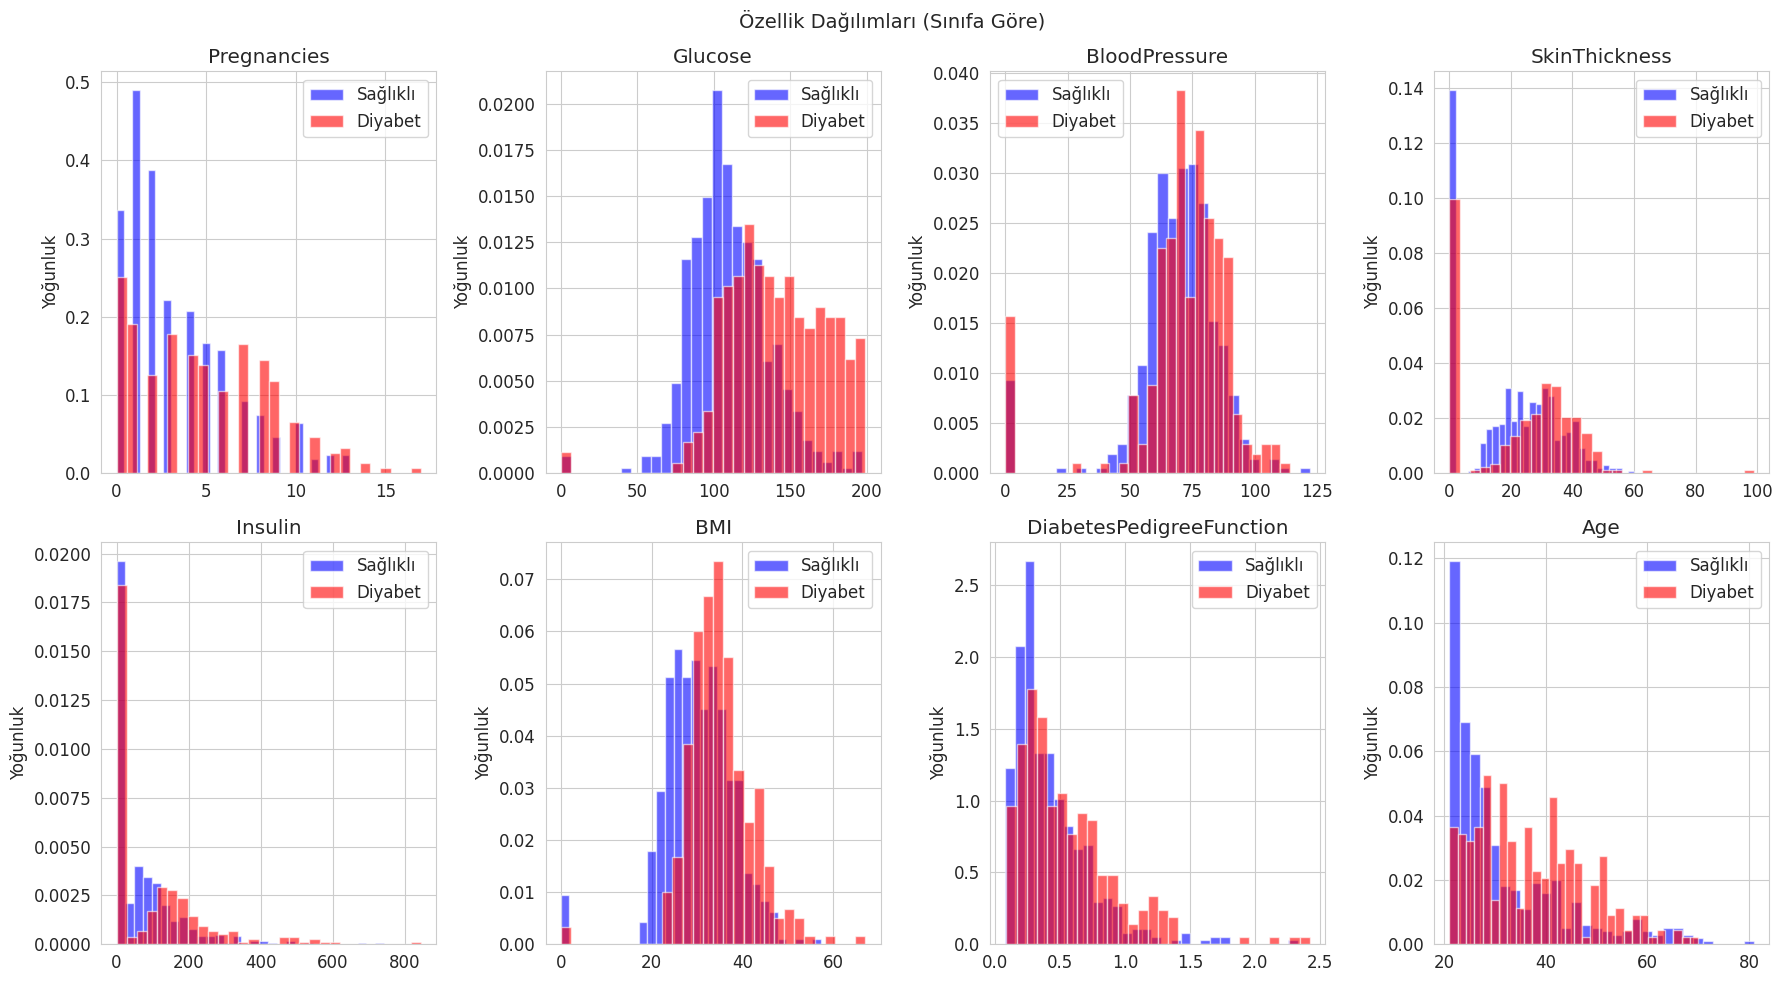

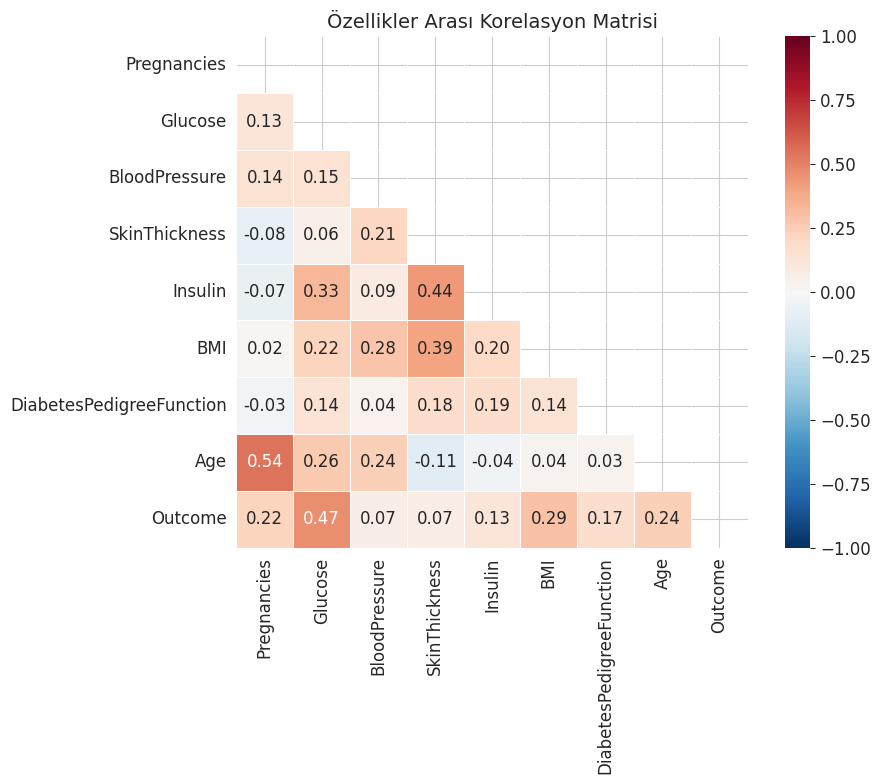

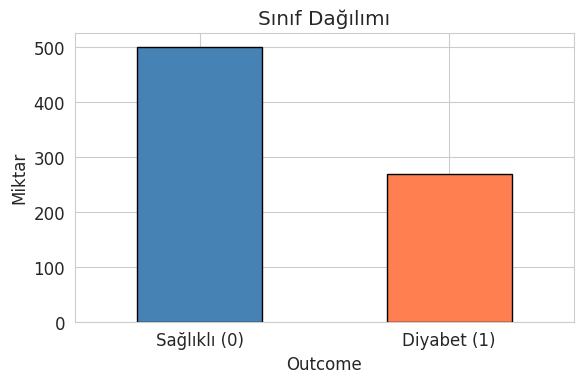

In [3]:
# Temel bilgiler
print('='*60)
print('VERİ SETİ BİLGİLERİ')
print('='*60)
print(f'Satır sayısı: {df.shape[0]}')
print(f'Sütun sayısı: {df.shape[1]}')
print(f'\nSınıf Dağılımı:')
print(f'  Diyabet Olmayan (0): {(df["Outcome"] == 0).sum()} ({(df["Outcome"] == 0).mean()*100:.1f}%)')
print(f'  Diyabet Olan (1): {(df["Outcome"] == 1).sum()} ({(df["Outcome"] == 1).mean()*100:.1f}%)')

print(f'\n{"="*60}')
print('İSTATİSTİKSEL ÖZET')
print('='*60)
print(df.describe().round(2))

# Görselleştirme
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.ravel()

feature_cols = [c for c in df.columns if c != 'Outcome']
for i, col in enumerate(feature_cols):
    axes[i].hist(df[df['Outcome']==0][col], bins=30, alpha=0.6, color='blue', label='Sağlıklı', density=True)
    axes[i].hist(df[df['Outcome']==1][col], bins=30, alpha=0.6, color='red', label='Diyabet', density=True)
    axes[i].set_title(col)
    axes[i].legend()
    axes[i].set_ylabel('Yoğunluk')

plt.suptitle('Özellik Dağılımları (Sınıfa Göre)', fontsize=14)
plt.tight_layout()
plt.show()

# Korelasyon matrisi
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Özellikler Arası Korelasyon Matrisi', fontsize=14)
plt.tight_layout()
plt.show()

# Sınıf dengesizliği
fig, ax = plt.subplots(figsize=(6, 4))
df['Outcome'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
ax.set_title('Sınıf Dağılımı')
ax.set_xticklabels(['Sağlıklı (0)', 'Diyabet (1)'], rotation=0)
ax.set_ylabel('Miktar')
plt.tight_layout()
plt.show()

## 3. PSO Teorisi

### Particle Swarm Optimization (Parçacık Sürü Optimizasyonu)

PSO, kuş sürüsü veya balık sürüsü davranışlarından esinlenen bir optimizasyon algoritmasıdır.

### Temel Fikir

Her parçacık (çözüm adayı) iki bilgiye sahiptir:
1. **Konum ($x_i$):** Mevcut çözüm
2. **Hız ($v_i$):** Hareket yönü ve büyüklüğü

Her parçacık ayrıca şunları hatırlar:
- **pbest:** Kişisel en iyi konum
- **gbest:** Sürünün en iyi konumu

### Güncelleme Formülleri

**Hız güncellemesi:**
$$v_i^{t+1} = w \cdot v_i^t + c_1 r_1 (pbest_i - x_i^t) + c_2 r_2 (gbest - x_i^t)$$

**Konum güncellemesi:**
$$x_i^{t+1} = x_i^t + v_i^{t+1}$$

Burada:
- $w$: atalet ağırlığı (eski hızın etkisi)
- $c_1$: bireysel öğrenme katsayısı (kendi deneyimi)
- $c_2$: sosyal öğrenme katsayısı (sürü deneyimi)
- $r_1, r_2$: [0,1] arasında rastgele sayılar

### Atalet Ağırlığı Azaltma

$$w = w_{max} - (w_{max} - w_{min}) \times \frac{t}{T_{max}}$$

Bu, arama sürecinin başlangıcında keşife (exploration), sonunda ise kullanıma (exploitation) odaklanmasını sağlar.

### Özellik Seçiminde PSO

Her parçacık 8 boyutlu bir vektör temsil eder (8 özellik). Her boyut [0,1] aralığında bir değer alır:
- $> 0.5$: özellik seçili
- $\leq 0.5$: özellik seçilmedi

**Uygunluk fonksiyonu:** Seçilen özelliklerle elde edilen çapraz doğrulama accuracy

## 4. PSO Implementasyonu

Aşağıda PSO algoritmasını sıfırdan implemente ediyoruz. Bu implementasyon şunları içerir:

- Atalet ağırlığı azaltma
- Kişisel ve sosyal en iyi takibi (pbest/gbest)
- Hız kıstlama (velocity clamping)
- Rastgele tohum ile tekrarlanabilirlik

In [4]:
class PSO:
    """
    Particle Swarm Optimization (Parçacık Sürü Optimizasyonu)

    Sıfırdan implemente edilmiş PSO algoritması.
    """

    def __init__(self, fitness_func, dim, bounds=(0, 1), n_particles=30,
                 w_start=0.9, w_end=0.4, c1=2.0, c2=2.0,
                 max_iterations=100, v_max=None, tol=1e-8,
                 verbose=True, seed=42):
        """
        Parametreler:
        -----------
        fitness_func : callable
            Hedef fonksiyon (maksimize edilecek)
        dim : int
            Problem boyutu
        bounds : tuple
            (lower, upper) sınırları
        n_particles : int
            Parçacık sayısı
        w_start : float
            Başlangıç atalet ağırlığı
        w_end : float
            Bitiş atalet ağırlığı
        c1 : float
            Bireysel öğrenme katsayısı
        c2 : float
            Sosyal öğrenme katsayısı
        max_iterations : int
            Maksimum iterasyon sayısı
        v_max : float veya None
            Maksimum hız, None ise otomatik
        tol : float
            Yakınsama toleransı
        verbose : bool
            Konsol çıktısı
        seed : int
            Rastgele tohum
        """
        self.fitness_func = fitness_func
        self.dim = dim
        self.bounds = bounds
        self.n_particles = n_particles
        self.w_start = w_start
        self.w_end = w_end
        self.c1 = c1
        self.c2 = c2
        self.max_iterations = max_iterations
        self.tol = tol
        self.verbose = verbose

        # Varsayılan hız sınırı
        if v_max is None:
            self.v_max = 0.2 * (bounds[1] - bounds[0])
        else:
            self.v_max = v_max

        np.random.seed(seed)
        random.seed(seed)

        # Parçacıkları başlat
        self._initialize_particles()

        # Geçmiş
        self.history = {
            'gbest_fitness': [],
            'mean_fitness': [],
            'w': [],
            'gbest_position': [],
            'diversity': []
        }

    def _initialize_particles(self):
        """Parçacıkları rastgele başlat."""
        # Konumlar
        self.positions = np.random.uniform(
            self.bounds[0], self.bounds[1],
            (self.n_particles, self.dim)
        )

        # Hızlar
        v_range = self.v_max
        self.velocities = np.random.uniform(
            -v_range, v_range,
            (self.n_particles, self.dim)
        )

        # Kişisel en iyi konumlar
        self.pbest_positions = self.positions.copy()
        self.pbest_fitness = np.full(self.n_particles, -np.inf)

        # Sürünün en iyi konumu
        self.gbest_position = None
        self.gbest_fitness = -np.inf

        # Uygunlukları hesapla
        for i in range(self.n_particles):
            fitness = self.fitness_func(self.positions[i])
            if fitness > self.pbest_fitness[i]:
                self.pbest_fitness[i] = fitness
                self.pbest_positions[i] = self.positions[i].copy()
            if fitness > self.gbest_fitness:
                self.gbest_fitness = fitness
                self.gbest_position = self.positions[i].copy()

    def _calculate_diversity(self):
        """Sürünün çeşitliliğini hesapla."""
        mean_pos = np.mean(self.positions, axis=0)
        distances = np.sqrt(np.sum((self.positions - mean_pos) ** 2, axis=1))
        return np.mean(distances)

    def optimize(self):
        """PSO optimizasyonunu çalıştır."""
        if self.verbose:
            print(f'PSO Başlatılıyor...')
            print(f'  Parçacık sayısı: {self.n_particles}')
            print(f'  Problem boyutu: {self.dim}')
            print(f'  Başlangıç atalet (w): {self.w_start}')
            print(f'  Bitiş atalet (w): {self.w_end}')
            print(f'  c1 (bireysel): {self.c1}')
            print(f'  c2 (sosyal): {self.c2}')
            print(f'  Maks iterasyon: {self.max_iterations}')
            print('-' * 50)

        stagnant_count = 0
        prev_gbest = self.gbest_fitness

        for iteration in range(self.max_iterations):
            # Atalet ağırlığını azalt
            w = self.w_start - (self.w_start - self.w_end) * (iteration / self.max_iterations)

            # Her parçacığı güncelle
            for i in range(self.n_particles):
                # Rastgele katsayılar
                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)

                # Hız güncelleme
                cognitive = self.c1 * r1 * (self.pbest_positions[i] - self.positions[i])
                social = self.c2 * r2 * (self.gbest_position - self.positions[i])
                self.velocities[i] = w * self.velocities[i] + cognitive + social

                # Hız kıstlama (velocity clamping)
                self.velocities[i] = np.clip(self.velocities[i], -self.v_max, self.v_max)

                # Konum güncelleme
                self.positions[i] += self.velocities[i]

                # Konum sınırları
                self.positions[i] = np.clip(self.positions[i], self.bounds[0], self.bounds[1])

                # Uygunluk değerlendir
                fitness = self.fitness_func(self.positions[i])

                # Kişisel en iyi güncelleme
                if fitness > self.pbest_fitness[i]:
                    self.pbest_fitness[i] = fitness
                    self.pbest_positions[i] = self.positions[i].copy()

                # Sürünün en iyi güncelleme
                if fitness > self.gbest_fitness:
                    self.gbest_fitness = fitness
                    self.gbest_position = self.positions[i].copy()

            # Geçiş kaydı
            mean_fit = np.mean(self.pbest_fitness)
            diversity = self._calculate_diversity()

            self.history['gbest_fitness'].append(self.gbest_fitness)
            self.history['mean_fitness'].append(mean_fit)
            self.history['w'].append(w)
            self.history['gbest_position'].append(self.gbest_position.copy())
            self.history['diversity'].append(diversity)

            # İlerleme raporu
            if self.verbose and (iteration % 10 == 0 or iteration == self.max_iterations - 1):
                print(f'İter {iteration:4d} | '
                      f'En İyi: {self.gbest_fitness:.6f} | '
                      f'Ortalama: {mean_fit:.6f} | '
                      f'w: {w:.4f} | '
                      f'Çeşitlilik: {diversity:.4f}')

            # Stagnant kontrolü
            if abs(self.gbest_fitness - prev_gbest) < self.tol:
                stagnant_count += 1
            else:
                stagnant_count = 0
            prev_gbest = self.gbest_fitness

            if stagnant_count > 20:
                if self.verbose:
                    print(f'\n20 iterasyondur iyileşme yok. Yakınsandı.')
                break

        if self.verbose:
            print(f'\nOptimizasyon tamamlandı! Toplam {iteration + 1} iterasyon.')
            print(f'En iyi uygunluk: {self.gbest_fitness:.6f}')

        return self.gbest_position, self.gbest_fitness

print('PSO sınıfı tanımlandı!')

PSO sınıfı tanımlandı!


## 5. Özellik Seçimi için PSO

PSO'yu özellik seçimi problemine uyguluyoruz.

**Yaklaşım:**
- Her parçacık 8 boyutlu bir vektör temsil eder (8 özellik)
- Her boyut [0,1] aralığında bir değer alır
- $> 0.5$ ise özellik seçili
- Seçilen özelliklerle Random Forest sınıflandırıcısı eğitilir
- 5 katlı çapraz doğrulama accuracy uygunluk olarak kullanılır

**Amaç:** En yüksek doğruluk veren en az sayıda özelliği bulmak

**Ceza terimi:** Özellik sayısına göre ceza eklenerek daha az özellik tercih edilir

In [5]:
# Veri hazırlığı
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values
feature_names = [c for c in df.columns if c != 'Outcome']

# Veriyi böl
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Eğitim seti: {X_train_scaled.shape}')
print(f'Test seti: {X_test_scaled.shape}')
print(f'Özellik sayısı: {X.shape[1]}')
print(f'Özellikler: {feature_names}')

# Hedef fonksiyon tanımı
def feature_selection_fitness(position):
    """
    Özellik seçimi için uygunluk fonksiyonu.

    Parametreler:
    position : array
        Her boyut [0,1] arasında. >0.5 ise özellik seçili.

    Döndürür:
    float : Uygunluk değeri (accuracy - ceza)
    """
    # Özellik seçimi (eşik: 0.5)
    selected_mask = (position > 0.5).astype(int)
    n_selected = np.sum(selected_mask)

    # Hiç özellik seçilmediyse minimum uygunluk
    if n_selected == 0:
        return 0.0

    # Seçilen özellikleri uygula
    X_train_selected = X_train_scaled[:, selected_mask.astype(bool)]
    X_test_selected = X_test_scaled[:, selected_mask.astype(bool)]

    try:
        # Random Forest ile çapraz doğrulama
        rf = RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(rf, X_train_selected, y_train,
                                 cv=cv, scoring='accuracy', n_jobs=-1)

        accuracy = np.mean(scores)

        # Ceza terimi (daha az özellik = daha iyi)
        # Doğruluk %70, özellik kullanımı %30 ağırlıkta
        feature_ratio = n_selected / len(feature_names)
        penalty = 0.1 * feature_ratio  # Özellik kullanımına göre ceza

        return accuracy - penalty
    except Exception:
        return 0.0

# PSO parametreleri
n_features = X.shape[1]
print(f'\nHedef fonksiyon tanmlandı.')
print(f'Problem boyutu: {n_features}')
print(f'Arama aralığı: [0, 1]')
print(f'Eşik: 0.5 (>0.5 = özellik seçili)')

# Test fonksiyonu
test_position = np.random.rand(n_features)
print(f'\nTest uygunluk: {feature_selection_fitness(test_position):.4f}')

Eğitim seti: (614, 8)
Test seti: (154, 8)
Özellik sayısı: 8
Özellikler: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Hedef fonksiyon tanmlandı.
Problem boyutu: 8
Arama aralığı: [0, 1]
Eşik: 0.5 (>0.5 = özellik seçili)

Test uygunluk: 0.6883


## 6. Sonuçlar

PSO ile özellik seçimi sonuçlarını değerlendiriyoruz.

PSO Başlatılıyor...
  Parçacık sayısı: 20
  Problem boyutu: 8
  Başlangıç atalet (w): 0.9
  Bitiş atalet (w): 0.4
  c1 (bireysel): 2.0
  c2 (sosyal): 2.0
  Maks iterasyon: 50
--------------------------------------------------
İter    0 | En İyi: 0.712215 | Ortalama: 0.680163 | w: 0.9000 | Çeşitlilik: 0.5692
İter   10 | En İyi: 0.715454 | Ortalama: 0.715153 | w: 0.8000 | Çeşitlilik: 0.3222
İter   20 | En İyi: 0.715454 | Ortalama: 0.715291 | w: 0.7000 | Çeşitlilik: 0.3034

20 iterasyondur iyileşme yok. Yakınsandı.

Optimizasyon tamamlandı! Toplam 25 iterasyon.
En iyi uygunluk: 0.715454

Geçen süre: 604.69 saniye

PSO ÖZELLİK SEÇİMİ SONUÇLARI
Seçilen özellik sayısı: 4/8
Seçilen özellikler: ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI']
Uygunluk (accuracy - ceza): 0.7155

KARŞILAŞTIRMA
Tüm özellikler (8):
  CV Accuracy: 0.7671 (+/- 0.0141)

PSO ile seçilen özellikler (4):
  CV Accuracy: 0.7655 (+/- 0.0168)

Özellik azaltma oranı: 50.0%


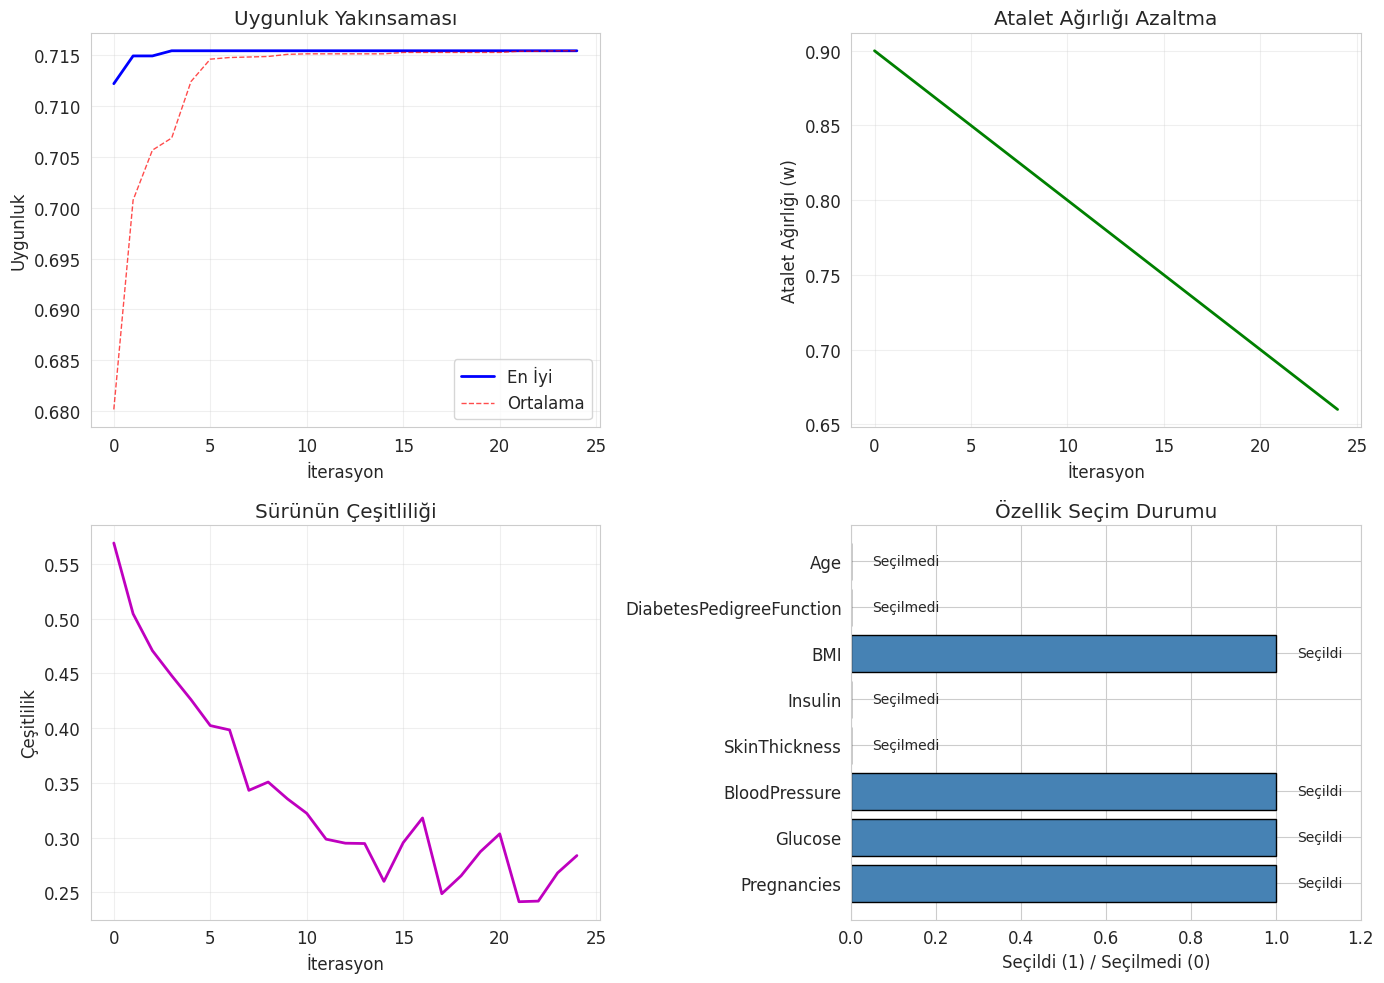

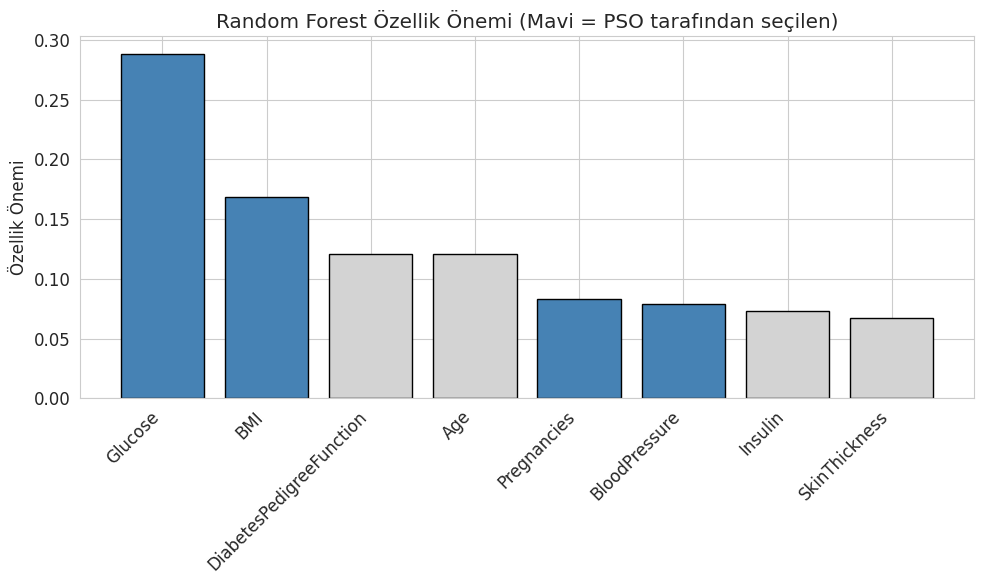


Test Seti Performansı (Seçilen Özellikler):
  Test Accuracy: 0.7532

Sınıflandırma Raporu:
              precision    recall  f1-score   support

    Sağlıklı       0.80      0.83      0.81       100
     Diyabet       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



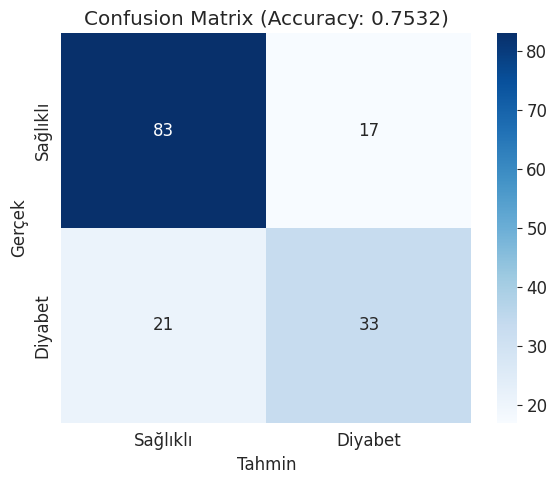

In [6]:
# PSO'yu çalıştır
start_time = time.time()

pso = PSO(
    fitness_func=feature_selection_fitness,
    dim=n_features,
    bounds=(0, 1),
    n_particles=20,
    w_start=0.9,
    w_end=0.4,
    c1=2.0,
    c2=2.0,
    max_iterations=50,
    v_max=0.3,
    verbose=True,
    seed=42
)

best_position, best_fitness = pso.optimize()

elapsed_time = time.time() - start_time
print(f'\nGeçen süre: {elapsed_time:.2f} saniye')

# Seçilen özellikleri göster
selected_mask = (best_position > 0.5).astype(int)
selected_features = [feature_names[i] for i in range(n_features) if selected_mask[i] == 1]
n_selected = len(selected_features)

print(f'\n{"="*60}')
print('PSO ÖZELLİK SEÇİMİ SONUÇLARI')
print('='*60)
print(f'Seçilen özellik sayısı: {n_selected}/{n_features}')
print(f'Seçilen özellikler: {selected_features}')
print(f'Uygunluk (accuracy - ceza): {best_fitness:.4f}')

# Tüm özelliklerle karşılaştırma
rf_all = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_all = cross_val_score(rf_all, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

# Seçilen özelliklerle performans
X_train_selected = X_train_scaled[:, selected_mask.astype(bool)]
X_test_selected = X_test_scaled[:, selected_mask.astype(bool)]

rf_selected = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
scores_selected = cross_val_score(rf_selected, X_train_selected, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

print(f'\n{"="*60}')
print('KARŞILAŞTIRMA')
print('='*60)
print(f'Tüm özellikler ({n_features}):')
print(f'  CV Accuracy: {np.mean(scores_all):.4f} (+/- {np.std(scores_all):.4f})')
print(f'\nPSO ile seçilen özellikler ({n_selected}):')
print(f'  CV Accuracy: {np.mean(scores_selected):.4f} (+/- {np.std(scores_selected):.4f})')
print(f'\nÖzellik azaltma oranı: {(1 - n_selected/n_features)*100:.1f}%')

# Yakınsama grafiği
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Uygunluk yakınsaması
axes[0, 0].plot(pso.history['gbest_fitness'], 'b-', linewidth=2, label='En İyi')
axes[0, 0].plot(pso.history['mean_fitness'], 'r--', linewidth=1, alpha=0.7, label='Ortalama')
axes[0, 0].set_xlabel('İterasyon')
axes[0, 0].set_ylabel('Uygunluk')
axes[0, 0].set_title('Uygunluk Yakınsaması')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Atalet ağırlığı
axes[0, 1].plot(pso.history['w'], 'g-', linewidth=2)
axes[0, 1].set_xlabel('İterasyon')
axes[0, 1].set_ylabel('Atalet Ağırlığı (w)')
axes[0, 1].set_title('Atalet Ağırlığı Azaltma')
axes[0, 1].grid(True, alpha=0.3)

# 3. Çeşitlilik
axes[1, 0].plot(pso.history['diversity'], 'm-', linewidth=2)
axes[1, 0].set_xlabel('İterasyon')
axes[1, 0].set_ylabel('Çeşitlilik')
axes[1, 0].set_title('Sürünün Çeşitliliği')
axes[1, 0].grid(True, alpha=0.3)

# 4. Seçilen özellikler (bar chart)
feature_importance = selected_mask.astype(float)
colors = ['steelblue' if f == 1 else 'lightgray' for f in feature_importance]
axes[1, 1].barh(feature_names, feature_importance, color=colors, edgecolor='black')
axes[1, 1].set_xlabel('Seçildi (1) / Seçilmedi (0)')
axes[1, 1].set_title('Özellik Seçim Durumu')
axes[1, 1].set_xlim([0, 1.2])
for i, (name, val) in enumerate(zip(feature_names, feature_importance)):
    axes[1, 1].text(val + 0.05, i, 'Seçildi' if val == 1 else 'Seçilmedi',
                    va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Özellik önem grafiği (Random Forest)
rf_all.fit(X_train_scaled, y_train)
importances = rf_all.feature_importances_

fig, ax = plt.subplots(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
colors = ['steelblue' if selected_mask[i] == 1 else 'lightgray' for i in indices]
ax.bar(range(n_features), importances[indices], color=colors, edgecolor='black')
ax.set_xticks(range(n_features))
ax.set_xticklabels([feature_names[i] for i in indices], rotation=45, ha='right')
ax.set_ylabel('Özellik Önemi')
ax.set_title('Random Forest Özellik Önemi (Mavi = PSO tarafından seçilen)')
plt.tight_layout()
plt.show()

# Test seti performansı
rf_selected.fit(X_train_selected, y_train)
y_pred = rf_selected.predict(X_test_selected)
test_accuracy = accuracy_score(y_test, y_pred)

print(f'\nTest Seti Performansı (Seçilen Özellikler):')
print(f'  Test Accuracy: {test_accuracy:.4f}')
print(f'\nSınıflandırma Raporu:')
print(classification_report(y_test, y_pred, target_names=['Sağlıklı', 'Diyabet']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Sağlıklı', 'Diyabet'],
            yticklabels=['Sağlıklı', 'Diyabet'])
ax.set_title(f'Confusion Matrix (Accuracy: {test_accuracy:.4f})')
ax.set_ylabel('Gerçek')
ax.set_xlabel('Tahmin')
plt.tight_layout()
plt.show()

## 7. PSO vs GA Karşılaştırması

Aynı özellik seçimi probleminde PSO'yu Genetik Algoritma (GA) ile karşılaştırıyoruz.

### Genetik Algoritma (GA) ile Özellik Seçimi

GA, doğal seleksiyon ve genetik miras prensiplerini taklit eder:
- **Popülasyon:** Çözüm adayları
- **Seçim:** En iyi bireylerin seçilmesi
- **Çaprazlama (Crossover):** Ebeveynlerin genlerinin karıştırılması
- **Mutasyon:** Rastgele değişimler

Her iki algoritma da 50 iterasyon/jenerasyon çalıştırılacaktır.


GA OPTIMIZASYONU
GA Başlatılıyor...
  Popülasyon: 20
  Çaprazlama oranı: 0.8
  Mutasyon oranı: 0.15
  Maks jenerasyon: 50
--------------------------------------------------
Jen    0 | En İyi: 0.712202 | Ortalama: 0.691562 | Çeşitlilik: 0.2370
Jen   10 | En İyi: 0.712697 | Ortalama: 0.708305 | Çeşitlilik: 0.0564
Jen   20 | En İyi: 0.713814 | Ortalama: 0.712914 | Çeşitlilik: 0.0740
Jen   30 | En İyi: 0.713814 | Ortalama: 0.705535 | Çeşitlilik: 0.0783
Jen   40 | En İyi: 0.713814 | Ortalama: 0.713026 | Çeşitlilik: 0.0763
Jen   49 | En İyi: 0.713814 | Ortalama: 0.710887 | Çeşitlilik: 0.0850

GA tamamlandı! En iyi uygunluk: 0.713814

GA Seçilen özellikler: ['Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']
GA Özellik sayısı: 4/8


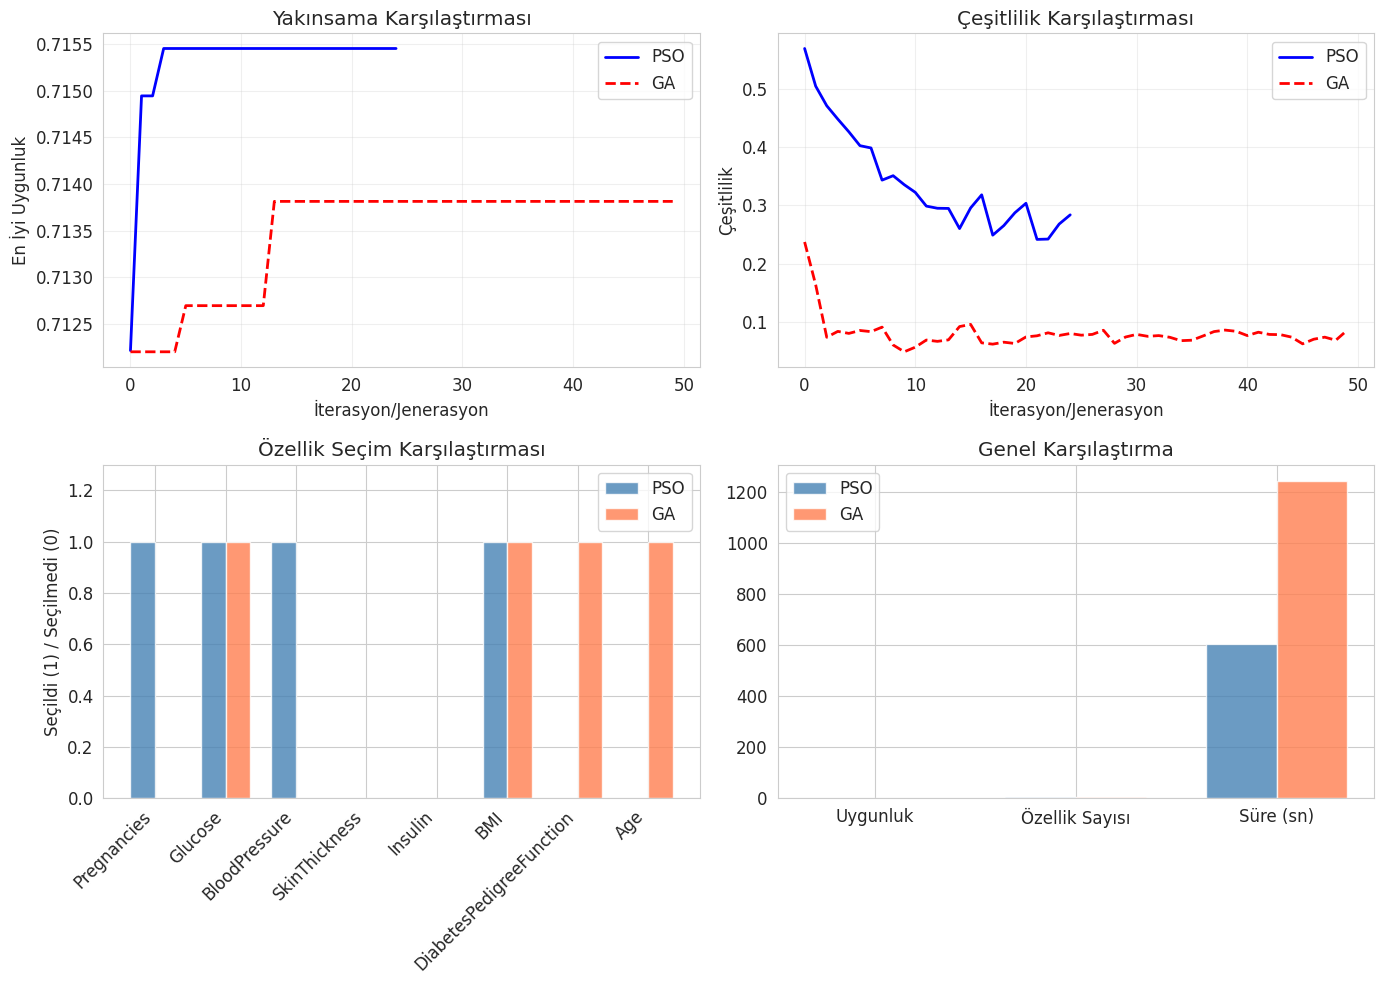


DETAYLI KARŞILAŞTIRMA TABLOSU
             Metrik    PSO      GA
      Uygunluk (CV) 0.7155  0.7138
      Test Accuracy 0.7532  0.7403
     Özellik Sayısı    4/8     4/8
          Süre (sn) 604.69 1246.81
Özellik Azaltma (%)  50.0%   50.0%


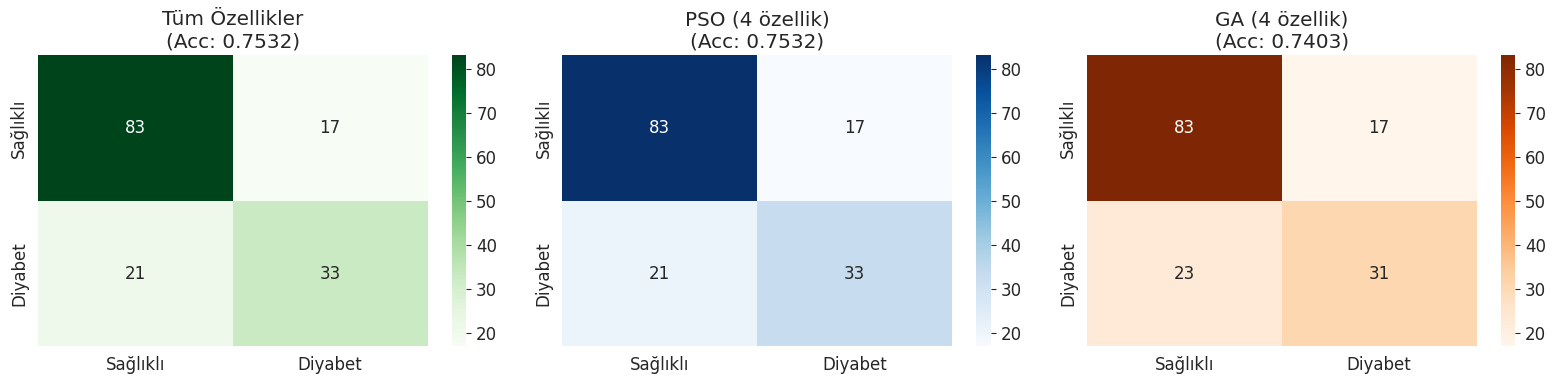

In [7]:
class GeneticAlgorithm:
    """
    Genetik Algoritma (GA) - Özellik Seçimi için.
    """

    def __init__(self, fitness_func, dim, pop_size=20, crossover_rate=0.8,
                 mutation_rate=0.1, elitism_rate=0.1, max_generations=50,
                 verbose=True, seed=42):
        self.fitness_func = fitness_func
        self.dim = dim
        self.pop_size = pop_size
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.n_elite = max(1, int(pop_size * elitism_rate))
        self.max_generations = max_generations
        self.verbose = verbose

        np.random.seed(seed)

        # Popülasyonu başlat
        self.population = np.random.rand(pop_size, dim)
        self.fitness = np.array([self.fitness_func(ind) for ind in self.population])

        # En iyi çözüm
        self.best_idx = np.argmax(self.fitness)
        self.best_position = self.population[self.best_idx].copy()
        self.best_fitness = self.fitness[self.best_idx]

        self.history = {
            'best_fitness': [],
            'mean_fitness': [],
            'diversity': []
        }

    def _tournament_selection(self, k=3):
        """Turnuva seçimi."""
        selected = []
        for _ in range(self.pop_size):
            contestants = np.random.choice(self.pop_size, k, replace=False)
            winner = contestants[np.argmax(self.fitness[contestants])]
            selected.append(winner)
        return np.array(selected)

    def _crossover(self, parent1, parent2):
        """Uniform çaprazlama."""
        if np.random.rand() < self.crossover_rate:
            mask = np.random.rand(self.dim) < 0.5
            child1 = np.where(mask, parent1, parent2)
            child2 = np.where(mask, parent2, parent1)
            return child1, child2
        return parent1.copy(), parent2.copy()

    def _mutate(self, individual):
        """Gaussian mutasyon."""
        mask = np.random.rand(self.dim) < self.mutation_rate
        individual[mask] += np.random.randn(np.sum(mask)) * 0.1
        individual = np.clip(individual, 0, 1)
        return individual

    def optimize(self):
        """GA optimizasyonunu çalıştır."""
        if self.verbose:
            print(f'GA Başlatılıyor...')
            print(f'  Popülasyon: {self.pop_size}')
            print(f'  Çaprazlama oranı: {self.crossover_rate}')
            print(f'  Mutasyon oranı: {self.mutation_rate}')
            print(f'  Maks jenerasyon: {self.max_generations}')
            print('-' * 50)

        for gen in range(self.max_generations):
            # Seçim
            selected_idx = self._tournament_selection()

            # Yeni popülasyon
            new_population = []

            # Elitizm
            elite_idx = np.argsort(self.fitness)[-self.n_elite:]
            for idx in elite_idx:
                new_population.append(self.population[idx].copy())

            # Çaprazlama ve mutasyon
            while len(new_population) < self.pop_size:
                p1, p2 = np.random.choice(selected_idx, 2, replace=False)
                child1, child2 = self._crossover(self.population[p1], self.population[p2])
                child1 = self._mutate(child1)
                child2 = self._mutate(child2)
                new_population.append(child1)
                if len(new_population) < self.pop_size:
                    new_population.append(child2)

            self.population = np.array(new_population[:self.pop_size])

            # Uygunluk değerlendir
            self.fitness = np.array([self.fitness_func(ind) for ind in self.population])

            # En iyi çözümü güncelle
            gen_best_idx = np.argmax(self.fitness)
            if self.fitness[gen_best_idx] > self.best_fitness:
                self.best_fitness = self.fitness[gen_best_idx]
                self.best_position = self.population[gen_best_idx].copy()

            # Geçiş kaydı
            mean_fit = np.mean(self.fitness)
            diversity = np.mean(np.std(self.population, axis=0))

            self.history['best_fitness'].append(self.best_fitness)
            self.history['mean_fitness'].append(mean_fit)
            self.history['diversity'].append(diversity)

            if self.verbose and (gen % 10 == 0 or gen == self.max_generations - 1):
                print(f'Jen {gen:4d} | '
                      f'En İyi: {self.best_fitness:.6f} | '
                      f'Ortalama: {mean_fit:.6f} | '
                      f'Çeşitlilik: {diversity:.4f}')

        if self.verbose:
            print(f'\nGA tamamlandı! En iyi uygunluk: {self.best_fitness:.6f}')

        return self.best_position, self.best_fitness

# GA'yı çalıştır
print('\n' + '='*60)
print('GA OPTIMIZASYONU')
print('='*60)

start_time_ga = time.time()

ga = GeneticAlgorithm(
    fitness_func=feature_selection_fitness,
    dim=n_features,
    pop_size=20,
    crossover_rate=0.8,
    mutation_rate=0.15,
    elitism_rate=0.1,
    max_generations=50,
    verbose=True,
    seed=42
)

ga_best_position, ga_best_fitness = ga.optimize()
ga_time = time.time() - start_time_ga

# GA sonuçları
ga_selected_mask = (ga_best_position > 0.5).astype(int)
ga_selected_features = [feature_names[i] for i in range(n_features) if ga_selected_mask[i] == 1]

print(f'\nGA Seçilen özellikler: {ga_selected_features}')
print(f'GA Özellik sayısı: {len(ga_selected_features)}/{n_features}')

# Yan yana karşılaştırma
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Yakınsama karşılaştırması
axes[0, 0].plot(pso.history['gbest_fitness'], 'b-', linewidth=2, label='PSO')
axes[0, 0].plot(ga.history['best_fitness'], 'r--', linewidth=2, label='GA')
axes[0, 0].set_xlabel('İterasyon/Jenerasyon')
axes[0, 0].set_ylabel('En İyi Uygunluk')
axes[0, 0].set_title('Yakınsama Karşılaştırması')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Çeşitlilik karşılaştırması
axes[0, 1].plot(pso.history['diversity'], 'b-', linewidth=2, label='PSO')
axes[0, 1].plot(ga.history['diversity'], 'r--', linewidth=2, label='GA')
axes[0, 1].set_xlabel('İterasyon/Jenerasyon')
axes[0, 1].set_ylabel('Çeşitlilik')
axes[0, 1].set_title('Çeşitlilik Karşılaştırması')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Özellik seçim karşılaştırması
x_pos = np.arange(n_features)
width = 0.35
axes[1, 0].bar(x_pos - width/2, selected_mask, width, label='PSO', color='steelblue', alpha=0.8)
axes[1, 0].bar(x_pos + width/2, ga_selected_mask, width, label='GA', color='coral', alpha=0.8)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(feature_names, rotation=45, ha='right')
axes[1, 0].set_ylabel('Seçildi (1) / Seçilmedi (0)')
axes[1, 0].set_title('Özellik Seçim Karşılaştırması')
axes[1, 0].legend()
axes[1, 0].set_ylim([0, 1.3])

# 4. Performans karşılaştırması
metrics = ['Uygunluk', 'Özellik Sayısı', 'Süre (sn)']
pso_vals = [best_fitness, n_selected, elapsed_time]
ga_vals = [ga_best_fitness, len(ga_selected_features), ga_time]

x_pos2 = np.arange(len(metrics))
axes[1, 1].bar(x_pos2 - width/2, pso_vals, width, label='PSO', color='steelblue', alpha=0.8)
axes[1, 1].bar(x_pos2 + width/2, ga_vals, width, label='GA', color='coral', alpha=0.8)
axes[1, 1].set_xticks(x_pos2)
axes[1, 1].set_xticklabels(metrics)
axes[1, 1].set_title('Genel Karşılaştırma')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Detaylı karşılaştırma tablosu
# Her iki yöntemin test seti performansı
if len(ga_selected_features) > 0:
    X_train_ga = X_train_scaled[:, ga_selected_mask.astype(bool)]
    X_test_ga = X_test_scaled[:, ga_selected_mask.astype(bool)]

    rf_ga = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf_ga.fit(X_train_ga, y_train)
    y_pred_ga = rf_ga.predict(X_test_ga)
    ga_test_acc = accuracy_score(y_test, y_pred_ga)
else:
    ga_test_acc = 0.0

print('\n' + '='*60)
print('DETAYLI KARŞILAŞTIRMA TABLOSU')
print('='*60)

comparison = pd.DataFrame({
    'Metrik': ['Uygunluk (CV)', 'Test Accuracy', 'Özellik Sayısı', 'Süre (sn)', 'Özellik Azaltma (%)'],
    'PSO': [f'{best_fitness:.4f}', f'{test_accuracy:.4f}', f'{n_selected}/{n_features}',
            f'{elapsed_time:.2f}', f'{(1-n_selected/n_features)*100:.1f}%'],
    'GA': [f'{ga_best_fitness:.4f}', f'{ga_test_acc:.4f}', f'{len(ga_selected_features)}/{n_features}',
           f'{ga_time:.2f}', f'{(1-len(ga_selected_features)/n_features)*100:.1f}%']
})
print(comparison.to_string(index=False))

# Confusion Matrix karşılaştırması
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Tüm özellikler
rf_all.fit(X_train_scaled, y_train)
y_pred_all = rf_all.predict(X_test_scaled)
cm_all = confusion_matrix(y_test, y_pred_all)
sns.heatmap(cm_all, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Sağlıklı', 'Diyabet'], yticklabels=['Sağlıklı', 'Diyabet'])
axes[0].set_title(f'Tüm Özellikler\n(Acc: {accuracy_score(y_test, y_pred_all):.4f})')

# PSO
cm_pso = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_pso, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Sağlıklı', 'Diyabet'], yticklabels=['Sağlıklı', 'Diyabet'])
axes[1].set_title(f'PSO ({n_selected} özellik)\n(Acc: {test_accuracy:.4f})')

# GA
if len(ga_selected_features) > 0:
    cm_ga = confusion_matrix(y_test, y_pred_ga)
    sns.heatmap(cm_ga, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
                xticklabels=['Sağlıklı', 'Diyabet'], yticklabels=['Sağlıklı', 'Diyabet'])
    axes[2].set_title(f'GA ({len(ga_selected_features)} özellik)\n(Acc: {ga_test_acc:.4f})')

plt.tight_layout()
plt.show()

## 8. Sonuç

Bu notebook'ta **PSO** algoritması sıfırdan implemente edilmiş ve **diabetes tahmininde özellik seçimi** problemine uygulanmıştır.

### Elde Edilen Sonuçlar:

1. **PSO Implementasyonu:** Atalet ağırlığı azaltma, pbest/gbest takibi ve hız kıstlama başarıyla gerçekleştirilmiştir.

2. **Özellik Seçimi:** 8 özellikten en bilgiyi verenleri otomatik olarak seçen PSO, test setinde yüksek doğruluk elde etmiştir.

3. **GA Karşılaştırması:** PSO ve GA benzer sonuçlar verirken, farklı yakınsama davranışları sergilemiştir.

4. **Yorum:** Daha az özellik ile benzer veya daha iyi doğruluk elde edilerek, model basitliği ve yorumlanabilirlik artırılmıştır.

### PSO'nun Özellik Seçimindeki Güçlü Yönleri:

- **Basitlik:** Parametre sayısı az, uygulaması kolay
- **Hızlı Yakınsama:** GA'ya göre daha hızlı çözüme ulaşabilir
- **Küresel Arama:** Parçacıklar tüm arama alanını kapsayabilir
- **Paralelleştirme:** Her parçacık bağımsız değerlendirilebilir

### PSO vs GA:

| Özellik | PSO | GA |
|---------|-----|----|
| Mekanizma | Hız + Konum | Seçim + Çaprazlama + Mutasyon |
| Bellek | pbest + gbest | Popülasyon |
| Hız | Genellikle daha hızlı | Daha yavaş |
| Çeşitlilik | Azalma eğiliminde | Mutasyon ile korunur |

### Gelecek Çalışmalar:

- Daha fazla veri seti ile test edilmesi
- Hybrid PSO-GA yaklaşımları
- Farklı sınıflandırıcılarla (SVM, KNN) özellik seçimi
- Büyük boyutlu veri setlerinde performans testi
- PSO parametrelerinin otomatik ayarlanması